In [1]:
#let's test the population data by country in comparaison to other data sources 
# the data was grouped by coutry and summed

In [ ]:
all_worldpop_by_ISO3_by_year_2000_2022.csv'

In [124]:
import sys
import os
import pandas as pd

# Add the previous directory to the system path
sys.path.insert(0, '..')

# Import the DATA_DIR from the config file (assuming it's in the previous directory)
from config import DATA_DIR

# Define the path to the population files
path_population_files = os.path.join(DATA_DIR, "population")

# Age categories for which the data has been saved
age_categories = ['all', '65_70_75_80', '0_1']

# Dictionary to store the data for each age category
pop_data_by_age = {}
pop_data_by_age_by_iso3 = {}
# Load the data for each age category
for age in age_categories:
    # Construct the file path for the current age category
    file_path = os.path.join(Path(path_population_files) / f"{age}_worldpop_by_admin1_by_year_2003_2021.csv")
    file_path_iso3 = os.path.join(Path(path_population_files) / f"{age}_worldpop_by_ISO3_by_year_2003_2021.csv")
   
    # Check if the file exists before trying to load it
    if os.path.exists(file_path):
        # Load the CSV into a DataFrame and store it in the dictionary
        pop_data_by_age[age] = pd.read_csv(file_path)
        pop_data_by_age_by_iso3[age] =  pd.read_csv(file_path_iso3)
        print(f"Loaded population data for {age}")
    else:
        print(f"File not found for {age}: {file_path}")

# Now pop_data_by_age will contain the data for each age category


Loaded population data for all
Loaded population data for 65_70_75_80
Loaded population data for 0_1


In [110]:
pop_data_by_age['all']

,Unnamed: 0,ADM1_ID,ISO3,ADM1_NAME,value,year
0,0,10019604B1094996199402,ALB,Berat,1.333961e+05,2003
1,1,10019604B11091570243697,ALB,Korçë,2.011256e+05,2003
2,2,10019604B18588012879070,ALB,Fier,3.481591e+05,2003
3,3,10019604B29738820438867,ALB,Gjirokastër,1.051734e+05,2003
4,4,10019604B30424798991477,ALB,Tiranë,5.121021e+05,2003
...,...,...,...,...,...,...
55437,55437,99731895B5260290378804,LKA,North Western Province,2.031779e+06,2021
55438,55438,99731895B60977758614393,LKA,Southern Province,2.017800e+06,2021
55439,55439,99731895B66209916164902,LKA,North Central Province,1.369710e+06,2021
55440,55440,99731895B77537271836321,LKA,Uva Province,1.353025e+06,2021


In [119]:
pop_data_by_age['all'][pop_data_by_age['all'].ADM1_NAME=='Wakayama Prefecture']

,Unnamed: 0,ADM1_ID,ISO3,ADM1_NAME,value,year
1692,1692,47310658B18585040133157,JPN,Wakayama Prefecture,1.009241e+06,2003
4610,4610,47310658B18585040133157,JPN,Wakayama Prefecture,1.006818e+06,2004
7528,7528,47310658B18585040133157,JPN,Wakayama Prefecture,9.952235e+05,2005
10446,10446,47310658B18585040133157,JPN,Wakayama Prefecture,9.874131e+05,2006
13364,13364,47310658B18585040133157,JPN,Wakayama Prefecture,9.769235e+05,2007
16282,16282,47310658B18585040133157,JPN,Wakayama Prefecture,9.770412e+05,2008
19200,19200,47310658B18585040133157,JPN,Wakayama Prefecture,9.762150e+05,2009
22118,22118,47310658B18585040133157,JPN,Wakayama Prefecture,9.915050e+05,2010
25036,25036,47310658B18585040133157,JPN,Wakayama Prefecture,9.673041e+05,2011
27954,27954,47310658B18585040133157,JPN,Wakayama Prefecture,9.477098e+05,2012


In [147]:
import pandas as pd
import os

# Path to your comparison file (under_5_population.csv)
comparison_file_path = os.path.join(DATA_DIR, 'population', 'under-5-population.csv')

# Load the under-5 population comparison data
comparison_data = pd.read_csv(comparison_file_path)

# Filter for historical data (<= 2020)
historical_data = comparison_data[comparison_data['Year'] <= 2020]

# Assume your own data is loaded as a DataFrame 'your_data'
# Here's an example structure of your data:
# your_data = pd.DataFrame({'ISO3': ..., 'value': ..., 'ADM1_ID': ..., 'ADM1_NAME': ..., 'year': ...})

# Function to compare your data to under-5 population data
def compare_population(your_data, comparison_data, threshold=0.10):
    flagged_data = []
    
    # Loop over each country in your dataset
    for country in your_data['ISO3'].unique():
        # Get the corresponding data for the country from your data and the comparison data
        your_country_data = your_data[your_data['ISO3'] == country]
        comparison_country_data = comparison_data[comparison_data['Code'] == country]
        
        # Merge the datasets by year
        merged_data = pd.merge(your_country_data, comparison_country_data, left_on='year', right_on='Year', how='inner')
        
        # Calculate the percentage difference
        merged_data['difference_percentage'] = 100 * (merged_data['value'] - merged_data['Population - Sex: all - Age: 0-4 - Variant: estimates']) / merged_data['Population - Sex: all - Age: 0-4 - Variant: estimates']
        
        # Flag if the difference is greater than the threshold (10%)
        if (abs(merged_data['difference_percentage']) > threshold * 100).any():
            # Append to flagged data list
            flagged_data.append(merged_data[['ISO3', 'year', 'value', 'Population - Sex: all - Age: 0-4 - Variant: estimates', 'difference_percentage']])
    
    # Concatenate all flagged data into a single DataFrame
    if flagged_data:
        flagged_data_df = pd.concat(flagged_data)
        return flagged_data_df
    else:
        return pd.DataFrame()  # Return an empty DataFrame if no countries are flagged

# Example usage
# Assuming your data is already loaded into a DataFrame named 'your_data'
flagged_countries_data = compare_population(pop_data_by_age_by_iso3['0_1'][pop_data_by_age_by_iso3['0_1'].year==2003], historical_data[historical_data.Year==2003])

# Show the flagged data with differences
print(flagged_countries_data)

# Optionally, save the flagged differences to a CSV file
#flagged_countries_data.to_csv('flagged_countries_population_differences.csv', index=False)


   ISO3  year         value  \
0   AFG  2003  4.113155e+06   
0   AGO  2003  4.101989e+06   
0   ALB  2003  2.056212e+05   
0   AND  2003  4.028645e+03   
0   ARE  2003  1.952703e+05   
..  ...   ...           ...   
0   VEN  2003  2.374954e+06   
0   VUT  2003  1.017949e+04   
0   WSM  2003  1.638868e+04   
0   YEM  2003  3.030430e+06   
0   ZWE  2003  1.706499e+06   

    Population - Sex: all - Age: 0-4 - Variant: estimates  \
0                                           4617455.0       
0                                           3288738.0       
0                                            250671.0       
0                                              3465.0       
0                                            291590.0       
..                                                ...       
0                                           2876597.0       
0                                             29239.0       
0                                             26623.0       
0                

In [149]:
flagged_countries_data

,ISO3,year,value,Population - Sex: all - Age: 0-4 - Variant: estimates,difference_percentage
0,AFG,2003,4.113155e+06,4617455.0,-10.921610
0,AGO,2003,4.101989e+06,3288738.0,24.728368
0,ALB,2003,2.056212e+05,250671.0,-17.971699
0,AND,2003,4.028645e+03,3465.0,16.266815
0,ARE,2003,1.952703e+05,291590.0,-33.032581
...,...,...,...,...,...
0,VEN,2003,2.374954e+06,2876597.0,-17.438782
0,VUT,2003,1.017949e+04,29239.0,-65.185241
0,WSM,2003,1.638868e+04,26623.0,-38.441638
0,YEM,2003,3.030430e+06,3730811.0,-18.772893


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_15706/2415404664.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flagged_data, x='ISO3', y='difference_percentage', palette="viridis")


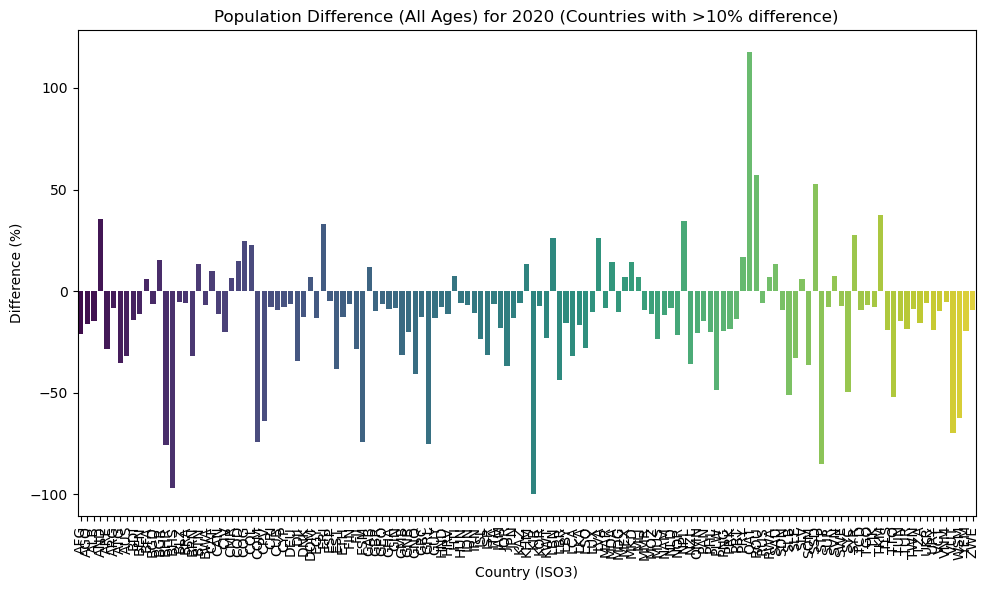

In [127]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

# Load the file containing population data for all ages
file_path_all_ages = os.path.join(DATA_DIR, 'population', 'population-and-demography.csv')

# Load the population data for all ages
population_all_ages_data = pd.read_csv(file_path_all_ages)
# Filter for historical data (<= 2020)

# Function to compare population differences for all ages and plot results
def plot_population_differences_all_ages(your_data, comparison_data, years_to_plot):
    for year in years_to_plot:
        # Filter your data and comparison data for the specific year
        your_year_data = your_data[your_data['year'] == year]
        comparison_year_data = comparison_data[comparison_data['Year'] == year]
        
        # Merge your data with the comparison data
        merged_data = pd.merge(your_year_data, comparison_year_data, left_on='ISO3', right_on='Code', how='inner')
        
        # Calculate the percentage difference
        merged_data['difference_percentage'] = 100 * (merged_data['value'] - merged_data['Population - Sex: all - Age: all - Variant: estimates']) / merged_data['Population - Sex: all - Age: all - Variant: estimates']
        # Filter for countries where the difference exceeds 10%
        flagged_data = merged_data[merged_data['difference_percentage'].abs() > 5]
        #return(merged_data)
        # Plot the results
        plt.figure(figsize=(10, 6))
        sns.barplot(data=flagged_data, x='ISO3', y='difference_percentage', palette="viridis")
        plt.xticks(rotation=90)
        plt.title(f'Population Difference (All Ages) for {year} (Countries with >10% difference)')
        plt.ylabel('Difference (%)')
        plt.xlabel('Country (ISO3)')
        plt.tight_layout()
        plt.show()
        return(merged_data)
# List of years to plot
years_to_plot = [2020]

# Call the function to plot differences for all ages
merged = plot_population_differences_all_ages(pop_data_by_age_by_iso3['all'], historical_data_all_ages, years_to_plot)


In [134]:
merged

,Unnamed: 0,value,ISO3,year,Entity,Code,Year,Population - Sex: all - Age: all - Variant: estimates,difference_percentage
0,17,3.079575e+07,AFG,2020,Afghanistan,AFG,2020,39068978,-21.175963
1,36,2.804866e+07,AGO,2020,Angola,AGO,2020,33451140,-16.150350
2,55,2.457082e+06,ALB,2020,Albania,ALB,2020,2871951,-14.445547
3,74,1.049635e+05,AND,2020,Andorra,AND,2020,77398,35.615312
4,93,6.759851e+06,ARE,2020,United Arab Emirates,ARE,2020,9448529,-28.456050
...,...,...,...,...,...,...,...,...,...
176,3361,7.969472e+04,WSM,2020,Samoa,WSM,2020,211958,-62.400700
177,3399,2.907983e+07,YEM,2020,Yemen,YEM,2020,36134868,-19.524183
178,3418,5.841266e+07,ZAF,2020,South Africa,ZAF,2020,60562374,-3.549587
179,3437,1.859825e+07,ZMB,2020,Zambia,ZMB,2020,19059395,-2.419534


In [136]:
merged[merged['Population - Sex: all - Age: all - Variant: estimates']>10e6]

,Unnamed: 0,value,ISO3,year,Entity,Code,Year,Population - Sex: all - Age: all - Variant: estimates,difference_percentage
0,17,3.079575e+07,AFG,2020,Afghanistan,AFG,2020,39068978,-21.175963
1,36,2.804866e+07,AGO,2020,Angola,AGO,2020,33451140,-16.150350
5,112,4.136398e+07,ARG,2020,Argentina,ARG,2020,45191960,-8.470490
8,169,1.750995e+07,AUS,2020,Australia,AUS,2020,25743787,-31.983799
10,207,9.677583e+06,AZE,2020,Azerbaijan,AZE,2020,10181736,-4.951542
...,...,...,...,...,...,...,...,...,...
174,3323,9.309963e+07,VNM,2020,Vietnam,VNM,2020,98079196,-5.077083
177,3399,2.907983e+07,YEM,2020,Yemen,YEM,2020,36134868,-19.524183
178,3418,5.841266e+07,ZAF,2020,South Africa,ZAF,2020,60562374,-3.549587
179,3437,1.859825e+07,ZMB,2020,Zambia,ZMB,2020,19059395,-2.419534


In [64]:
pop_data_by_age_by_iso3['all'][pop_data_by_age_by_iso3['all'].year==2020].value.sum()

7959989876.906914

In [24]:
import sys
import os
import pandas as pd

# Add the previous directory to the system path
sys.path.insert(0, '..')

# Import the DATA_DIR from the config file (assuming it's in the previous directory)
from config import DATA_DIR

# Define the path to the population files
path_population_files = os.path.join(DATA_DIR, "population")

# Age categories for which the data has been saved
age_categories = ['all', '65_70_75_80', '0_1']

# Dictionary to store the data for each age category at ADM1 level
pop_data_by_adm1 = {}

# Load the data for each age category
for age in age_categories:
    # Construct the file path for the current age category for ADM1 level
    file_path_adm1 = os.path.join(path_population_files, f"{age}_worldpop_by_admin1_by_year_2000_2022.csv")
    
    # Check if the file exists before trying to load it
    if os.path.exists(file_path_adm1):
        # Load the CSV into a DataFrame and store it in the dictionary for ADM1
        pop_data_by_adm1[age] = pd.read_csv(file_path_adm1)
        print(f"Loaded population data by ADM1 for {age}")
    else:
        print(f"File not found for ADM1 data: {file_path_adm1}")

# You now have pop_data_by_adm1 dictionary containing the population data at ADM1 level for each age category.


Loaded population data by ADM1 for all
Loaded population data by ADM1 for 65_70_75_80
Loaded population data by ADM1 for 0_1


In [32]:
import pandas as pd
import os

# Load your datasets
# Assuming your data is already loaded as 'pop_data_by_adm1' for your population data
# Path to the new population admin level data
pop_admin_level_1_path = os.path.join(DATA_DIR, 'population', 'Population_Administrative_Level_1.csv')

# Load the Population Administrative Level 1 data
pop_admin_level_1 = pd.read_csv(pop_admin_level_1_path)

# Load your ADM1 population data (assuming it's already loaded into pop_data_by_adm1['all'])
your_adm1_data = pop_data_by_adm1['all']

# Remove rows where the population value is 0 (which you want to treat as NaN)
pop_admin_level_1 = pop_admin_level_1[pop_admin_level_1.iloc[:, -2] != 0]

# Merge the two datasets based on ADM1_ID and ISO3 columns
# Assuming the columns in both datasets have 'ISO3' and 'ADM1_NAME' (or equivalent)
merged_data = pd.merge(your_adm1_data, pop_admin_level_1, left_on=['ISO3', 'ADM1_NAME'], right_on=['GID_0', 'VARNAME_1'], how='outer')

# Drop rows where there is a mismatch or NaN in either dataset
merged_data.dropna(inplace=True)

# You can now inspect the merged data or further analyze it
print(merged_data.head())

# Display summary of merged data
print("Comparison Summary:")
print(merged_data.describe())

# Optionally, you can save the merged data to a CSV file
output_path = os.path.join(DATA_DIR, 'population', 'merged_population_comparison_dropped_nan.csv')
merged_data.to_csv(output_path, index=False)
print(f"Comparison data saved to {output_path}")


      Unnamed: 0                  ADM1_ID ISO3 ADM1_NAME        value    year  \
4294       226.0  14850775B22712718081002  UKR      Kyiv  1705658.250  2003.0   
4295      2965.0  14850775B22712718081002  UKR      Kyiv  1710781.750  2004.0   
4296      5704.0  14850775B22712718081002  UKR      Kyiv  1710273.500  2005.0   
4297      8443.0  14850775B22712718081002  UKR      Kyiv  1723778.000  2006.0   
4298     11182.0  14850775B22712718081002  UKR      Kyiv  1750620.125  2007.0   

         FID GID_0   NAME_0     GID_1  ... HASC_1 ISO2 Region Continent  \
4294  3316.0   UKR  Ukraine  UKR.11_1  ...  UA.KC   UA   EURO    Europe   
4295  3316.0   UKR  Ukraine  UKR.11_1  ...  UA.KC   UA   EURO    Europe   
4296  3316.0   UKR  Ukraine  UKR.11_1  ...  UA.KC   UA   EURO    Europe   
4297  3316.0   UKR  Ukraine  UKR.11_1  ...  UA.KC   UA   EURO    Europe   
4298  3316.0   UKR  Ukraine  UKR.11_1  ...  UA.KC   UA   EURO    Europe   

           UN_Region      UN_SubRegi Population Wmn_Repro Shap

In [33]:
pop_admin_level_1

,FID,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO2,Region,Continent,UN_Region,UN_SubRegi,Population,Wmn_Repro,Shape__Area,Shape__Length
0,1,AFG,Afghanistan,AFG.1_1,Badakhshan,Badahšan,,Velayat,Province,,AF.BD,AF,EMRO,Asia,Southern Asia,Southern Asia,0.000000e+00,0.000000e+00,4.431195,18.376050
1,2,AFG,Afghanistan,AFG.2_1,Badghis,Badghes|Badghisat|Badgis,,Velayat,Province,,AF.BG,AF,EMRO,Asia,Southern Asia,Southern Asia,0.000000e+00,0.000000e+00,2.040874,7.190291
2,3,AFG,Afghanistan,AFG.3_1,Baghlan,Baglan|Bughlan,,Velayat,Province,,AF.BL,AF,EMRO,Asia,Southern Asia,Southern Asia,0.000000e+00,0.000000e+00,2.103677,8.218431
3,4,AFG,Afghanistan,AFG.4_1,Balkh,Balh|Mazar-i-Sharif|Mazar,,Velayat,Province,,AF.BK,AF,EMRO,Asia,Southern Asia,Southern Asia,0.000000e+00,0.000000e+00,1.738941,7.028352
4,5,AFG,Afghanistan,AFG.5_1,Bamyan,,,Velayat,Province,,AF.BM,AF,EMRO,Asia,Southern Asia,Southern Asia,0.000000e+00,0.000000e+00,1.397766,7.215632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3606,3607,ZWE,Zimbabwe,ZWE.7_1,Masvingo,,,Province,Province,,ZW.MV,ZW,AFRO,Africa,Sub-Saharan Africa,Eastern Africa,1.984487e+06,1.652412e+06,4.885235,11.103997
3607,3608,ZWE,Zimbabwe,ZWE.8_1,Matabeleland North,,,Province,Province,,ZW.MN,ZW,AFRO,Africa,Sub-Saharan Africa,Eastern Africa,9.672952e+05,7.624054e+05,6.472717,15.600981
3608,3609,ZWE,Zimbabwe,ZWE.9_1,Matabeleland South,,,Province,Province,,ZW.MS,ZW,AFRO,Africa,Sub-Saharan Africa,Eastern Africa,8.649773e+05,6.155331e+05,4.751254,15.211711
3609,3610,ZWE,Zimbabwe,ZWE.10_1,Midlands,,,Province,Province,,ZW.MI,ZW,AFRO,Africa,Sub-Saharan Africa,Eastern Africa,2.126400e+06,2.359104e+06,4.241882,14.492040


In [38]:
merged_data = merged_data[merged_data["Population"]>0]

In [50]:
merged_data["diff"] = (merged_data["value"] - merged_data["Population"])/merged_data["Population"]

In [60]:
merged_data[(merged_data["diff"]>0.5)&(merged_data["value"]>1e6)]

,Unnamed: 0,ADM1_ID,ISO3,ADM1_NAME,value,year,FID,GID_0,NAME_0,GID_1,...,ISO2,Region,Continent,UN_Region,UN_SubRegi,Population,Wmn_Repro,Shape__Area,Shape__Length,diff
29460,28940.0,43142294B97480278452280,DZA,Tiaret,1.013404e+06,2013.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,12.404845
29461,31679.0,43142294B97480278452280,DZA,Tiaret,1.037720e+06,2014.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,12.726484
29462,34418.0,43142294B97480278452280,DZA,Tiaret,1.063359e+06,2015.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,13.065625
29463,37157.0,43142294B97480278452280,DZA,Tiaret,1.092664e+06,2016.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,13.453262
29464,39896.0,43142294B97480278452280,DZA,Tiaret,1.123785e+06,2017.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,13.864918
29465,42635.0,43142294B97480278452280,DZA,Tiaret,1.160107e+06,2018.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,14.345367
29466,45374.0,43142294B97480278452280,DZA,Tiaret,1.200292e+06,2019.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,14.876918
29467,48113.0,43142294B97480278452280,DZA,Tiaret,1.240478e+06,2020.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,15.408470
29468,50852.0,43142294B97480278452280,DZA,Tiaret,1.280773e+06,2021.0,791.0,DZA,Algeria,DZA.44_1,...,DZ,AFRO,Africa,Northern Africa,Northern Africa,7.559983e+04,20871.884324,14.782972,15.996464,15.941477
36786,7414.0,63759600B22652371205312,VNM,Long An,2.407915e+06,2005.0,3502.0,VNM,Vietnam,VNM.39_1,...,VN,WPRO,Asia,South-eastern Asia,South-eastern Asia,1.576327e+06,441350.567265,0.373833,4.148889,0.527548


In [ ]:
# --> the other dataset appears to be off her

In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_data['percentage_difference'], bins=30, kde=True)
plt.title('Distribution of Population Percentage Differences')
plt.xlabel('Percentage Difference')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting the distribution of absolute population differences
plt.figure(figsize=(10, 6))
sns.histplot(merged_data['population_difference'], bins=30, kde=True)
plt.title('Distribution of Absolute Population Differences')
plt.xlabel('Absolute Difference in Population')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

KeyError: 'percentage_difference'

<Figure size 1000x600 with 0 Axes>